In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('/content/drive/MyDrive/DV SKILL /healthcare_dataset.csv')

Demographics by Medical Condition:
  Medical Condition  Patient_Count  Average_Age
0         Arthritis           9308    51.565320
1            Asthma           9185    51.575830
2            Cancer           9227    51.558795
3          Diabetes           9304    51.554170
4      Hypertension           9245    51.741915
5           Obesity           9231    51.240277


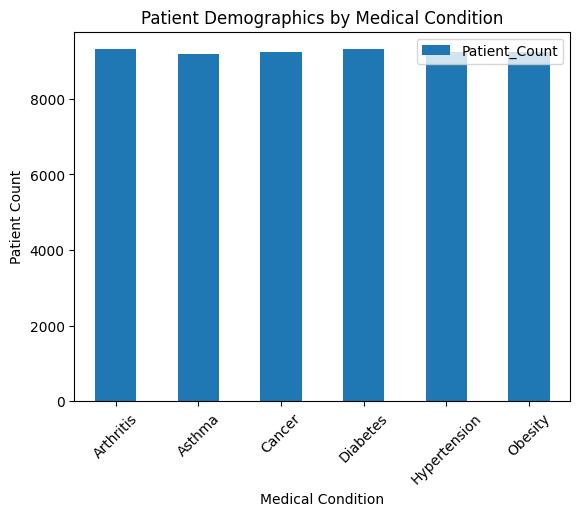

In [11]:
demographic = df.groupby('Medical Condition').agg(
    Patient_Count=('Name', 'count'),
    Average_Age=('Age', 'mean')
).reset_index()

print("Demographics by Medical Condition:")
print(demographic)

demographic.plot(x='Medical Condition', y='Patient_Count', kind='bar')
plt.title('Patient Demographics by Medical Condition')
plt.xlabel('Medical Condition')
plt.ylabel('Patient Count')
plt.xticks(rotation=45)
plt.show()

In [13]:
df['Medical Condition'] = df['Medical Condition'].fillna('Unknown')
df['Date of Admission'] = pd.to_datetime(
    df['Date of Admission'], errors='coerce'
)

df['Discharge Date'] = pd.to_datetime(
    df['Discharge Date'], errors='coerce'
)

print("\nMissing Values:")
print(df[['Medical Condition', 'Date of Admission', 'Discharge Date']].isnull().sum())


Missing Values:
Medical Condition    0
Date of Admission    0
Discharge Date       0
dtype: int64



Admission Urgency:
Urgency
Elective     18655
Urgent       18576
Emergency    18269
Name: count, dtype: int64


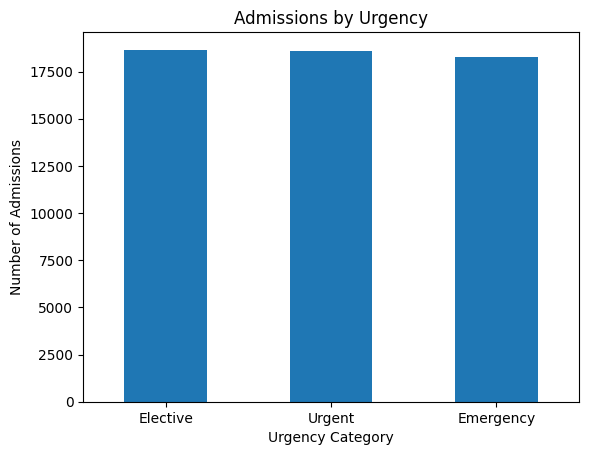

In [14]:
df['Admission Type'] = df['Admission Type'].astype(str).str.strip().str.title()

df['Urgency'] = df['Admission Type'].apply(
    lambda x: x if x in ['Emergency', 'Elective', 'Urgent'] else 'Unknown'
)

print("\nAdmission Urgency:")
print(df['Urgency'].value_counts())

df['Urgency'].value_counts().plot(kind='bar')
plt.title('Admissions by Urgency')
plt.xlabel('Urgency Category')
plt.ylabel('Number of Admissions')
plt.xticks(rotation=0)
plt.show()

In [15]:
df['Hospital Stay Days'] = (
    df['Discharge Date'] - df['Date of Admission']
).dt.days

print("\nBilling Amount Summary Statistics:")
print(df['Billing Amount'].describe())

print("\nHospital Stay Summary Statistics:")
print(df['Hospital Stay Days'].describe())


Billing Amount Summary Statistics:
count    55500.000000
mean     25539.316097
std      14211.454431
min      -2008.492140
25%      13241.224652
50%      25538.069376
75%      37820.508436
max      52764.276736
Name: Billing Amount, dtype: float64

Hospital Stay Summary Statistics:
count    55500.000000
mean        15.509009
std          8.659600
min          1.000000
25%          8.000000
50%         15.000000
75%         23.000000
max         30.000000
Name: Hospital Stay Days, dtype: float64


In [7]:
billing_summary = df['Billing Amount'].describe()

print("\nBilling Amount Summary Statistics:")
print(billing_summary)


Billing Amount Summary Statistics:
count    55500.000000
mean     25539.316097
std      14211.454431
min      -2008.492140
25%      13241.224652
50%      25538.069376
75%      37820.508436
max      52764.276736
Name: Billing Amount, dtype: float64


In [8]:
df['Hospital Stay Days'] = (
    df['Discharge Date'] - df['Date of Admission']
).dt.days

stay_summary = df['Hospital Stay Days'].describe()

print("\nHospital Stay Summary Statistics:")
print(stay_summary)


Hospital Stay Summary Statistics:
count    55500.000000
mean        15.509009
std          8.659600
min          1.000000
25%          8.000000
50%         15.000000
75%         23.000000
max         30.000000
Name: Hospital Stay Days, dtype: float64
